In [ ]:
# Aggressively uninstall all potentially conflicting packages
%pip uninstall -y scikit-learn scipy numpy umap-learn

# Install numpy version 1.x explicitly to resolve the '_center' ImportError
%pip install numpy==1.23.5

# Install a scipy version compatible with numpy 1.x (e.g., scipy==1.11.5)
%pip install scipy==1.11.5

# Reinstall scikit-learn and umap-learn to ensure compatibility
%pip install scikit-learn umap-learn[full]

# Note: A runtime restart is recommended after these installations to ensure all modules are loaded correctly.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from umap import UMAP
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import umap.umap_ as umap

df = pd.read_csv('Chicago_Crimes_2012_to_2017.csv')
df = df[df['Year'] == 2017]

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: umap-learn 0.5.12
Uninstalling umap-learn-0.5.12:
  Successfully uninstalled umap-learn-0.5.12
  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This erro

Les variables du dataframe :
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')
(11357, 23)
Types des variables : 
 Unnamed: 0                int64
ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
Beat                      int64
District                float64
Ward                    float64
Community Area          float64
FBI Code                 object
X Coordinate            float64
Y Coordinate            float64
Year           

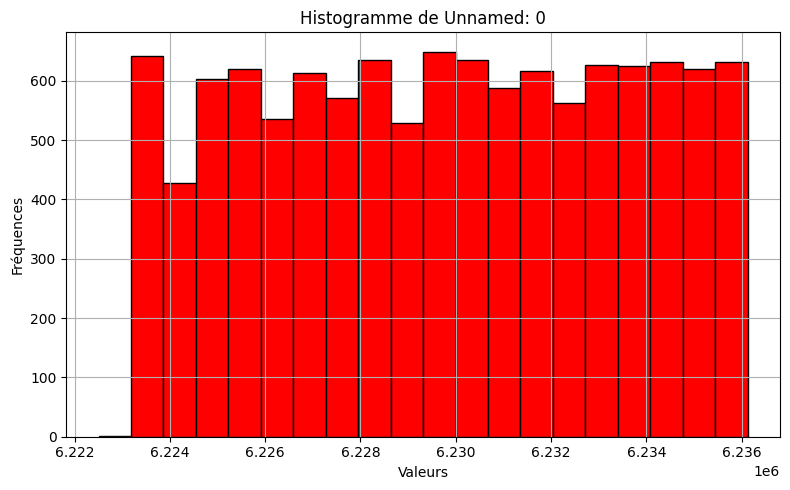

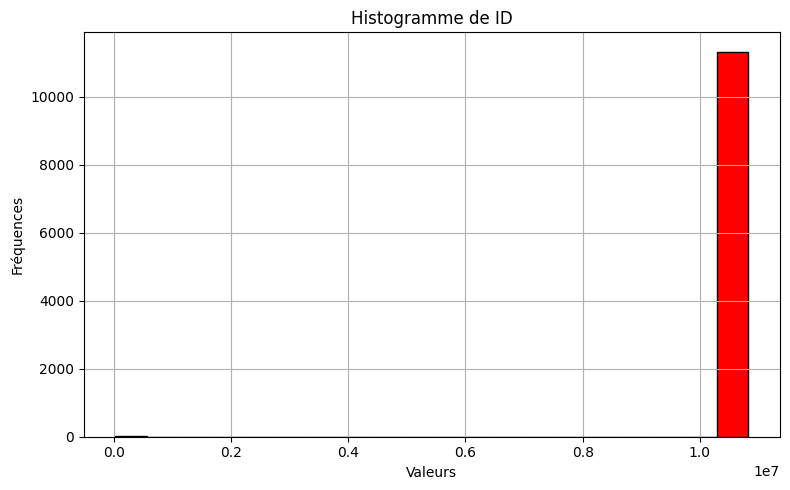

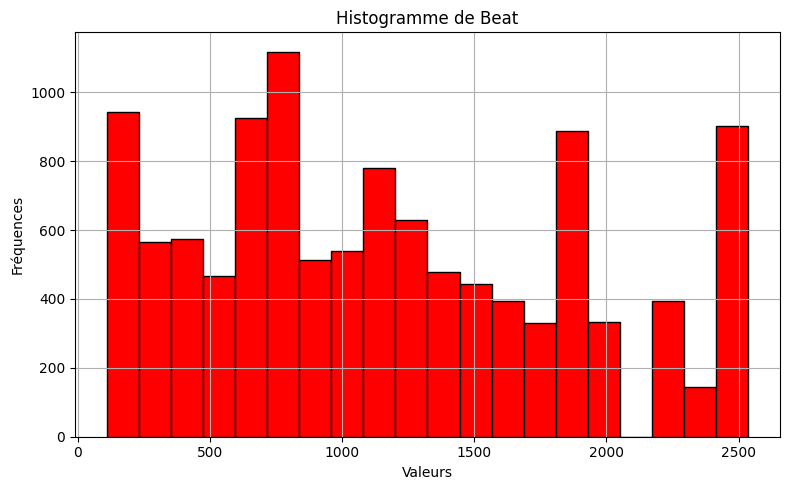

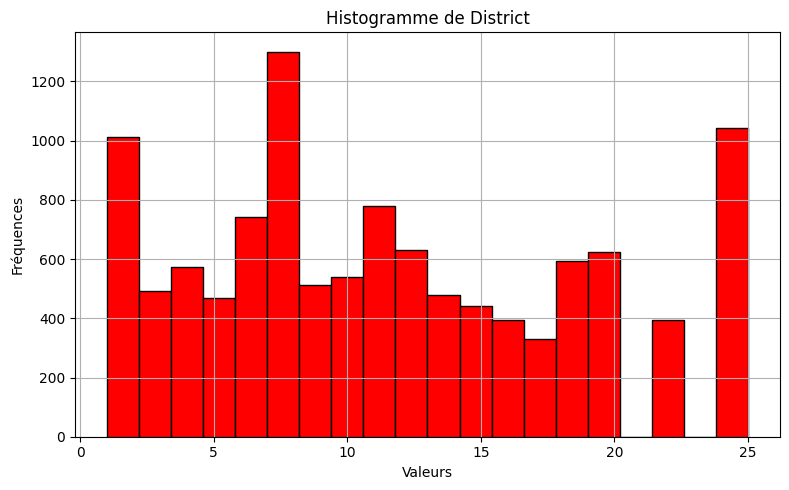

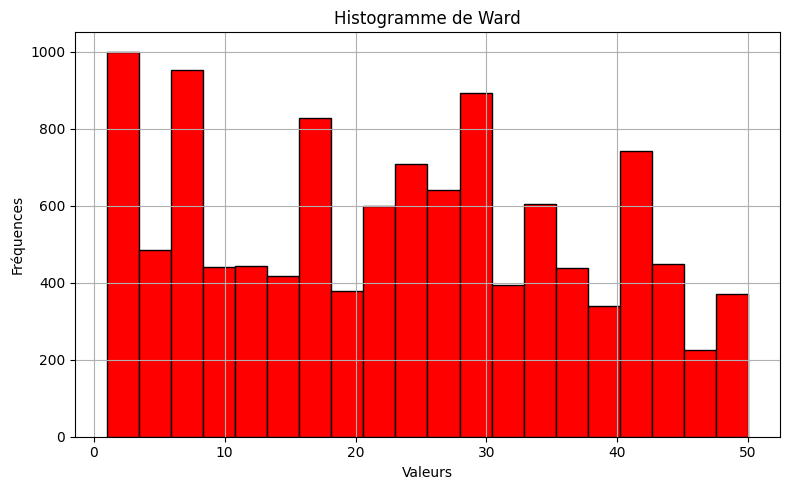

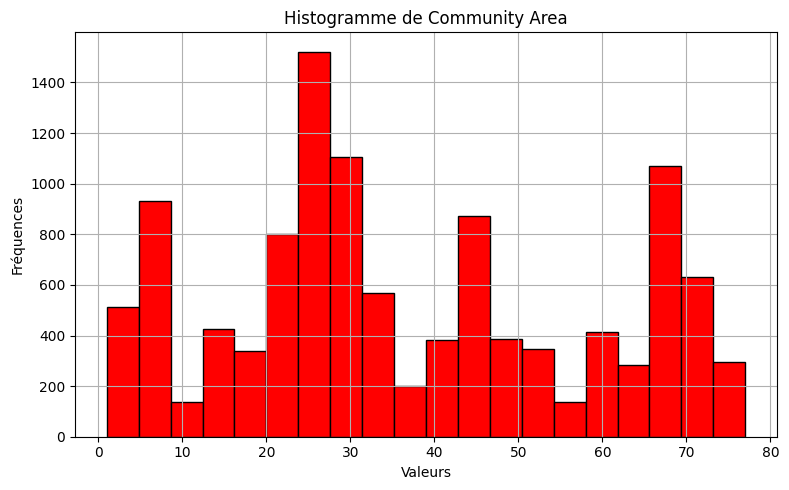

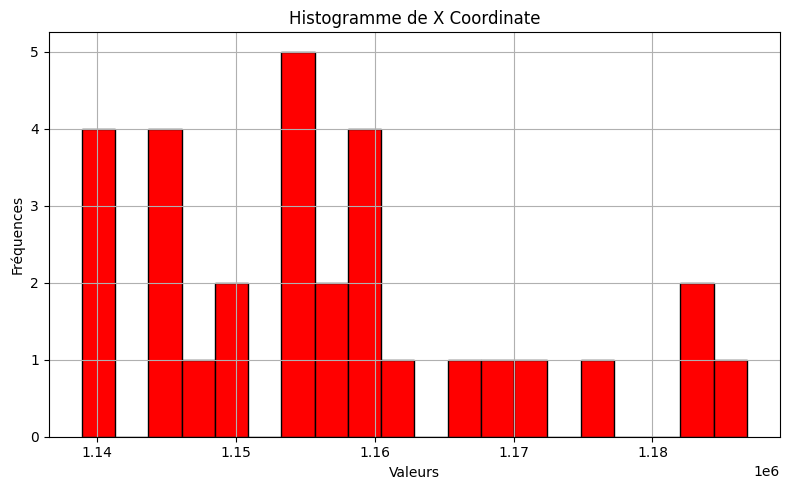

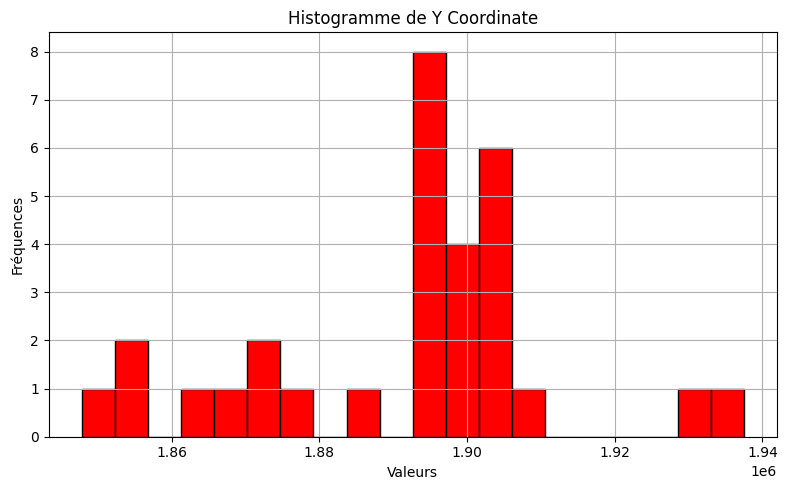

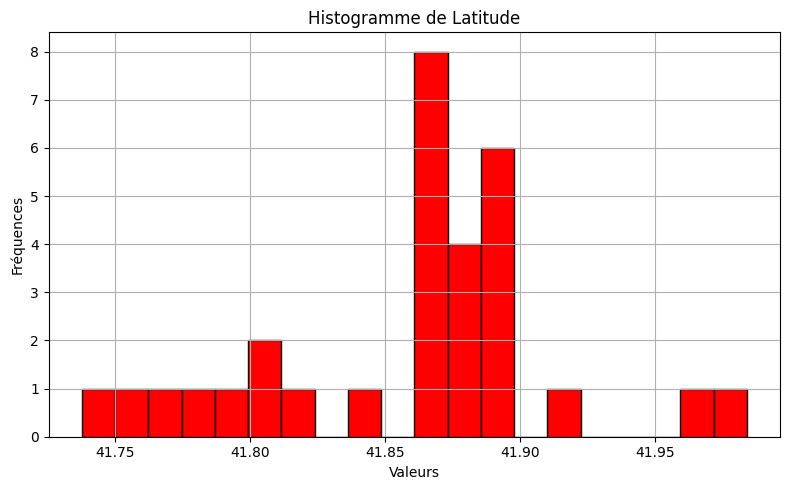

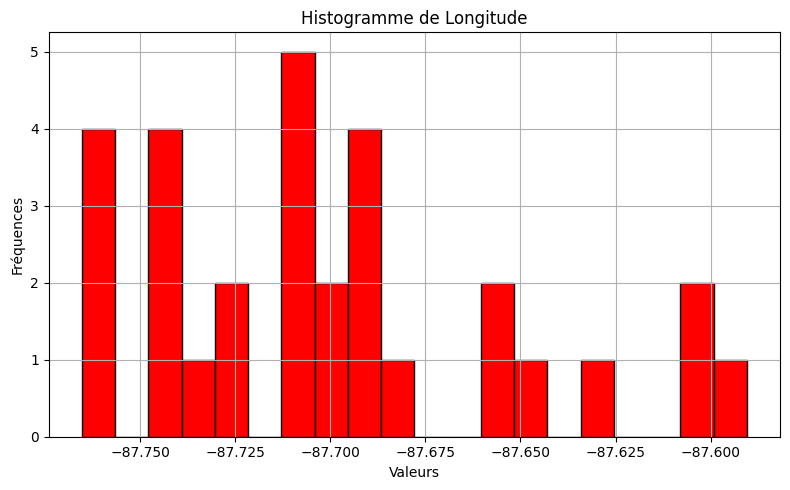

Boxplots :


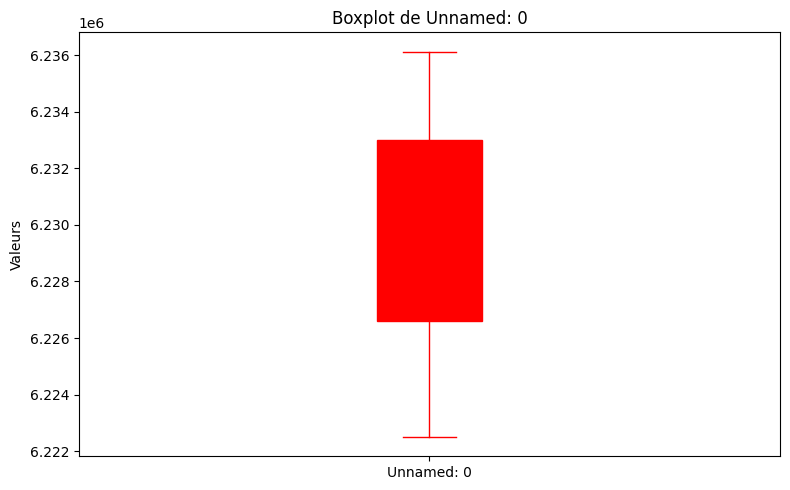

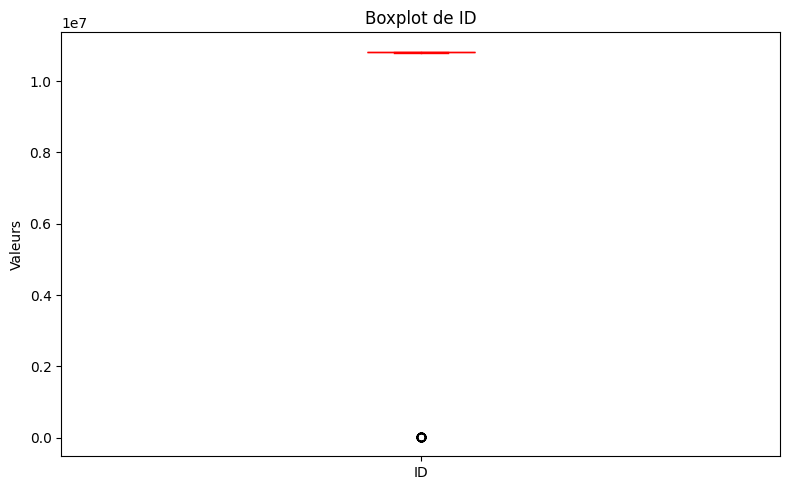

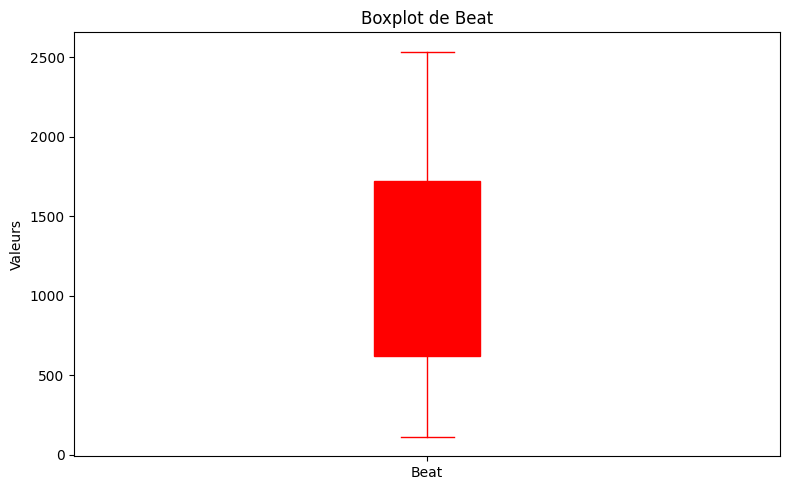

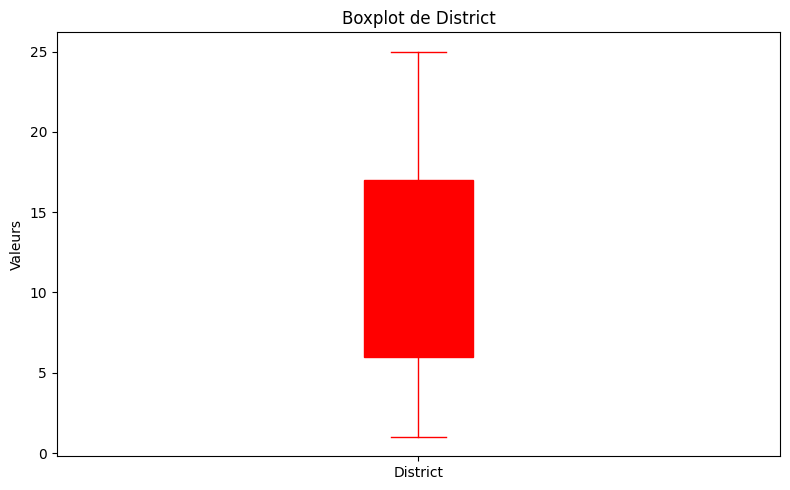

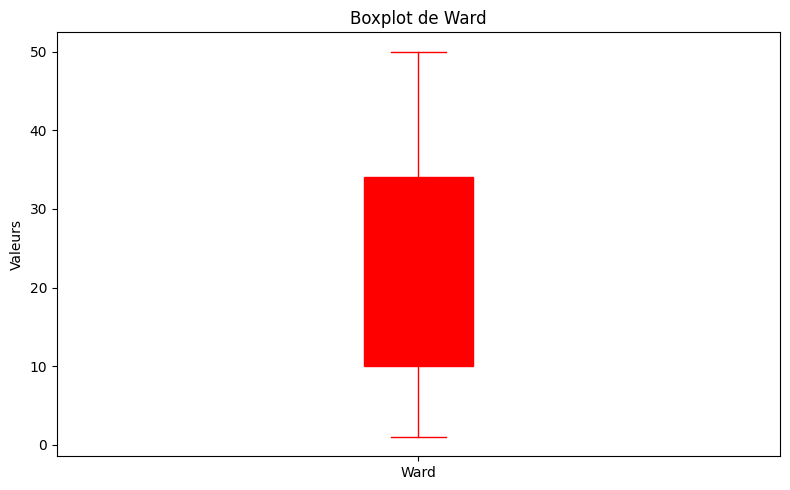

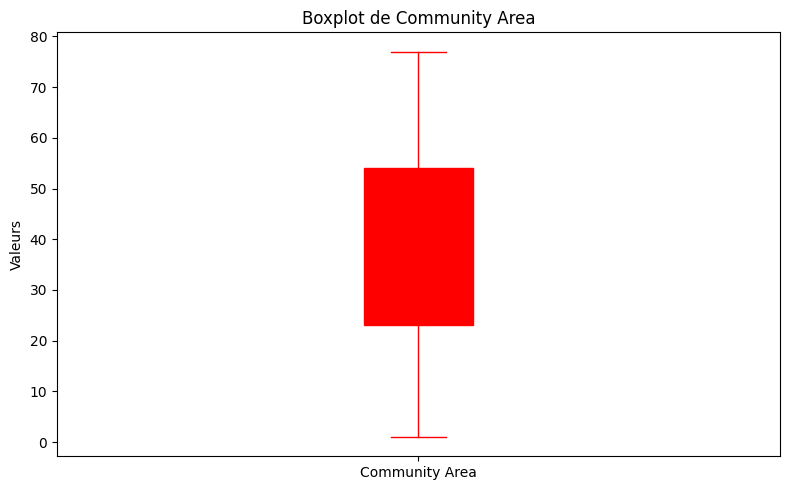

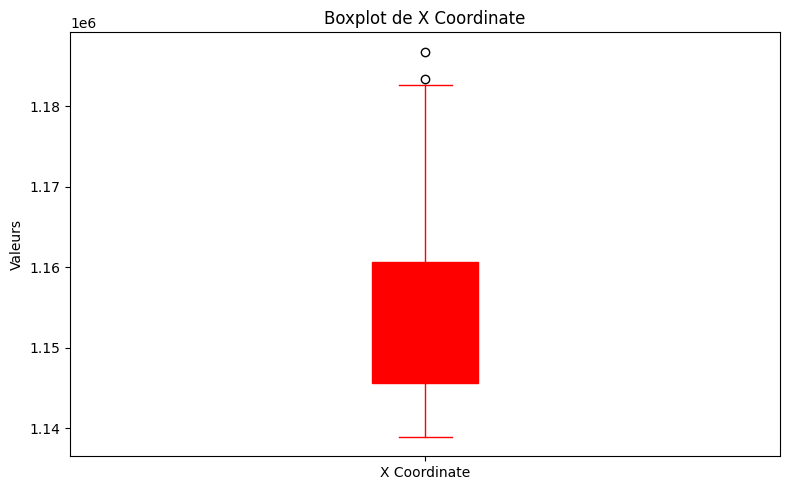

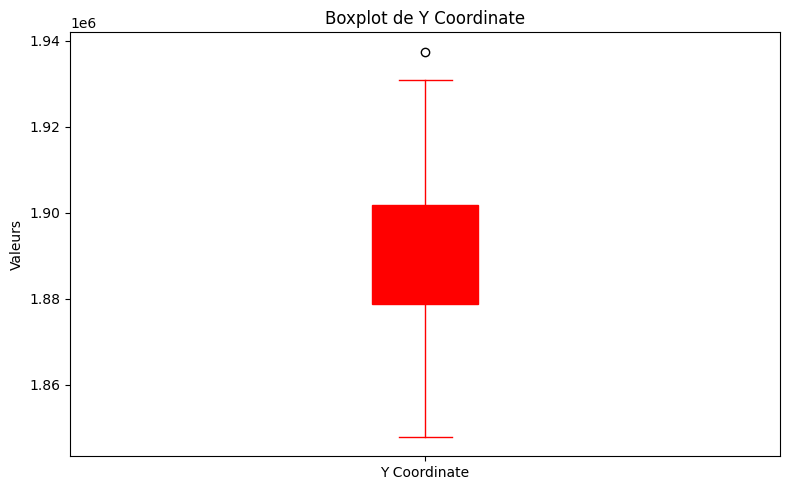

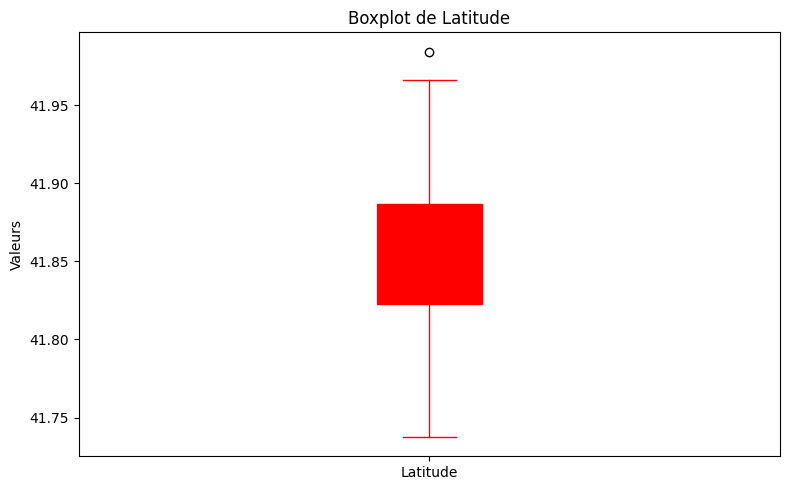

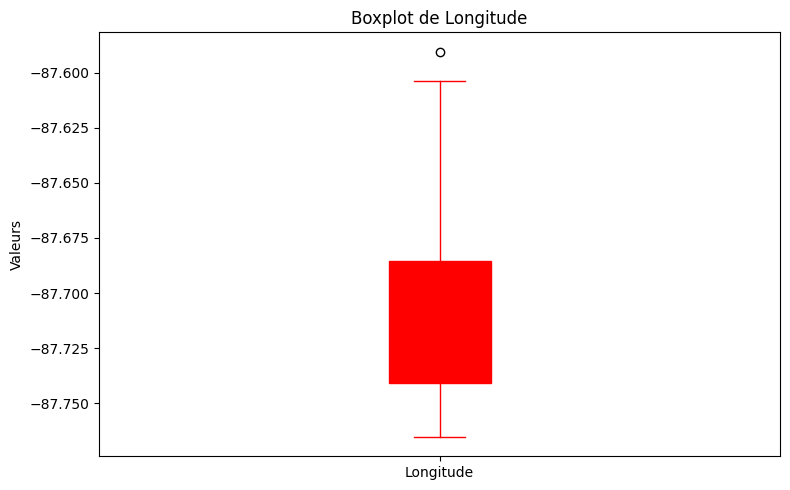

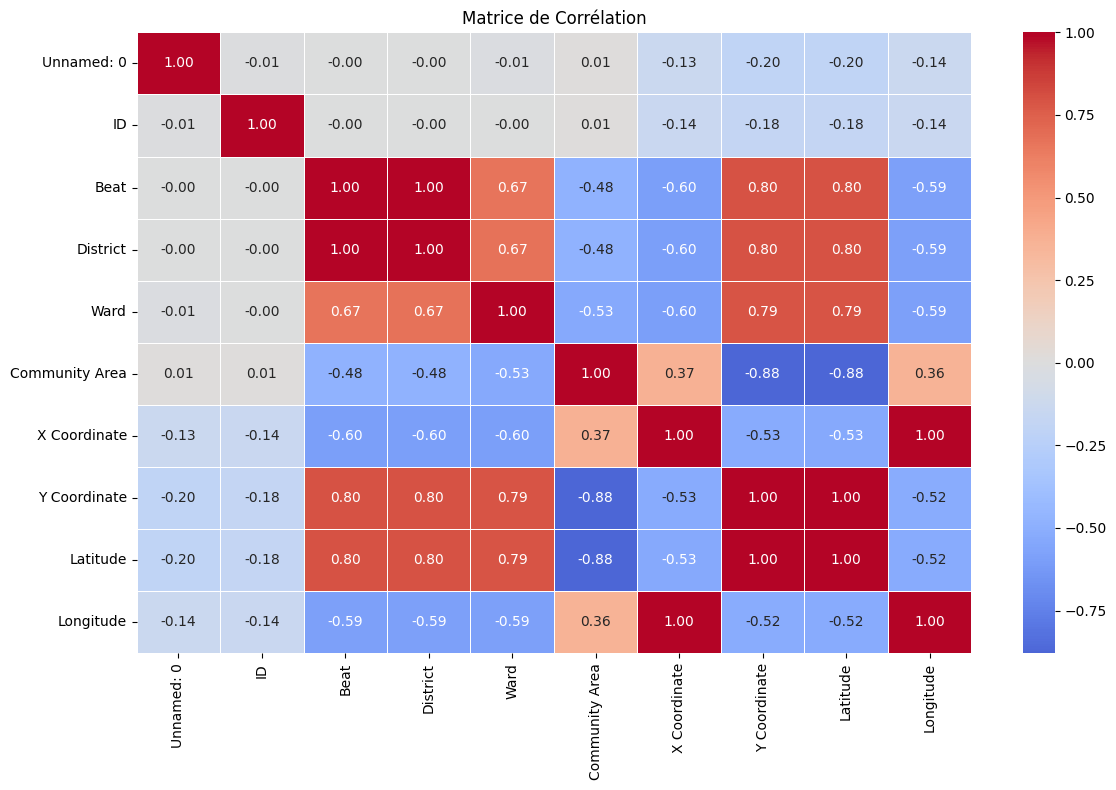

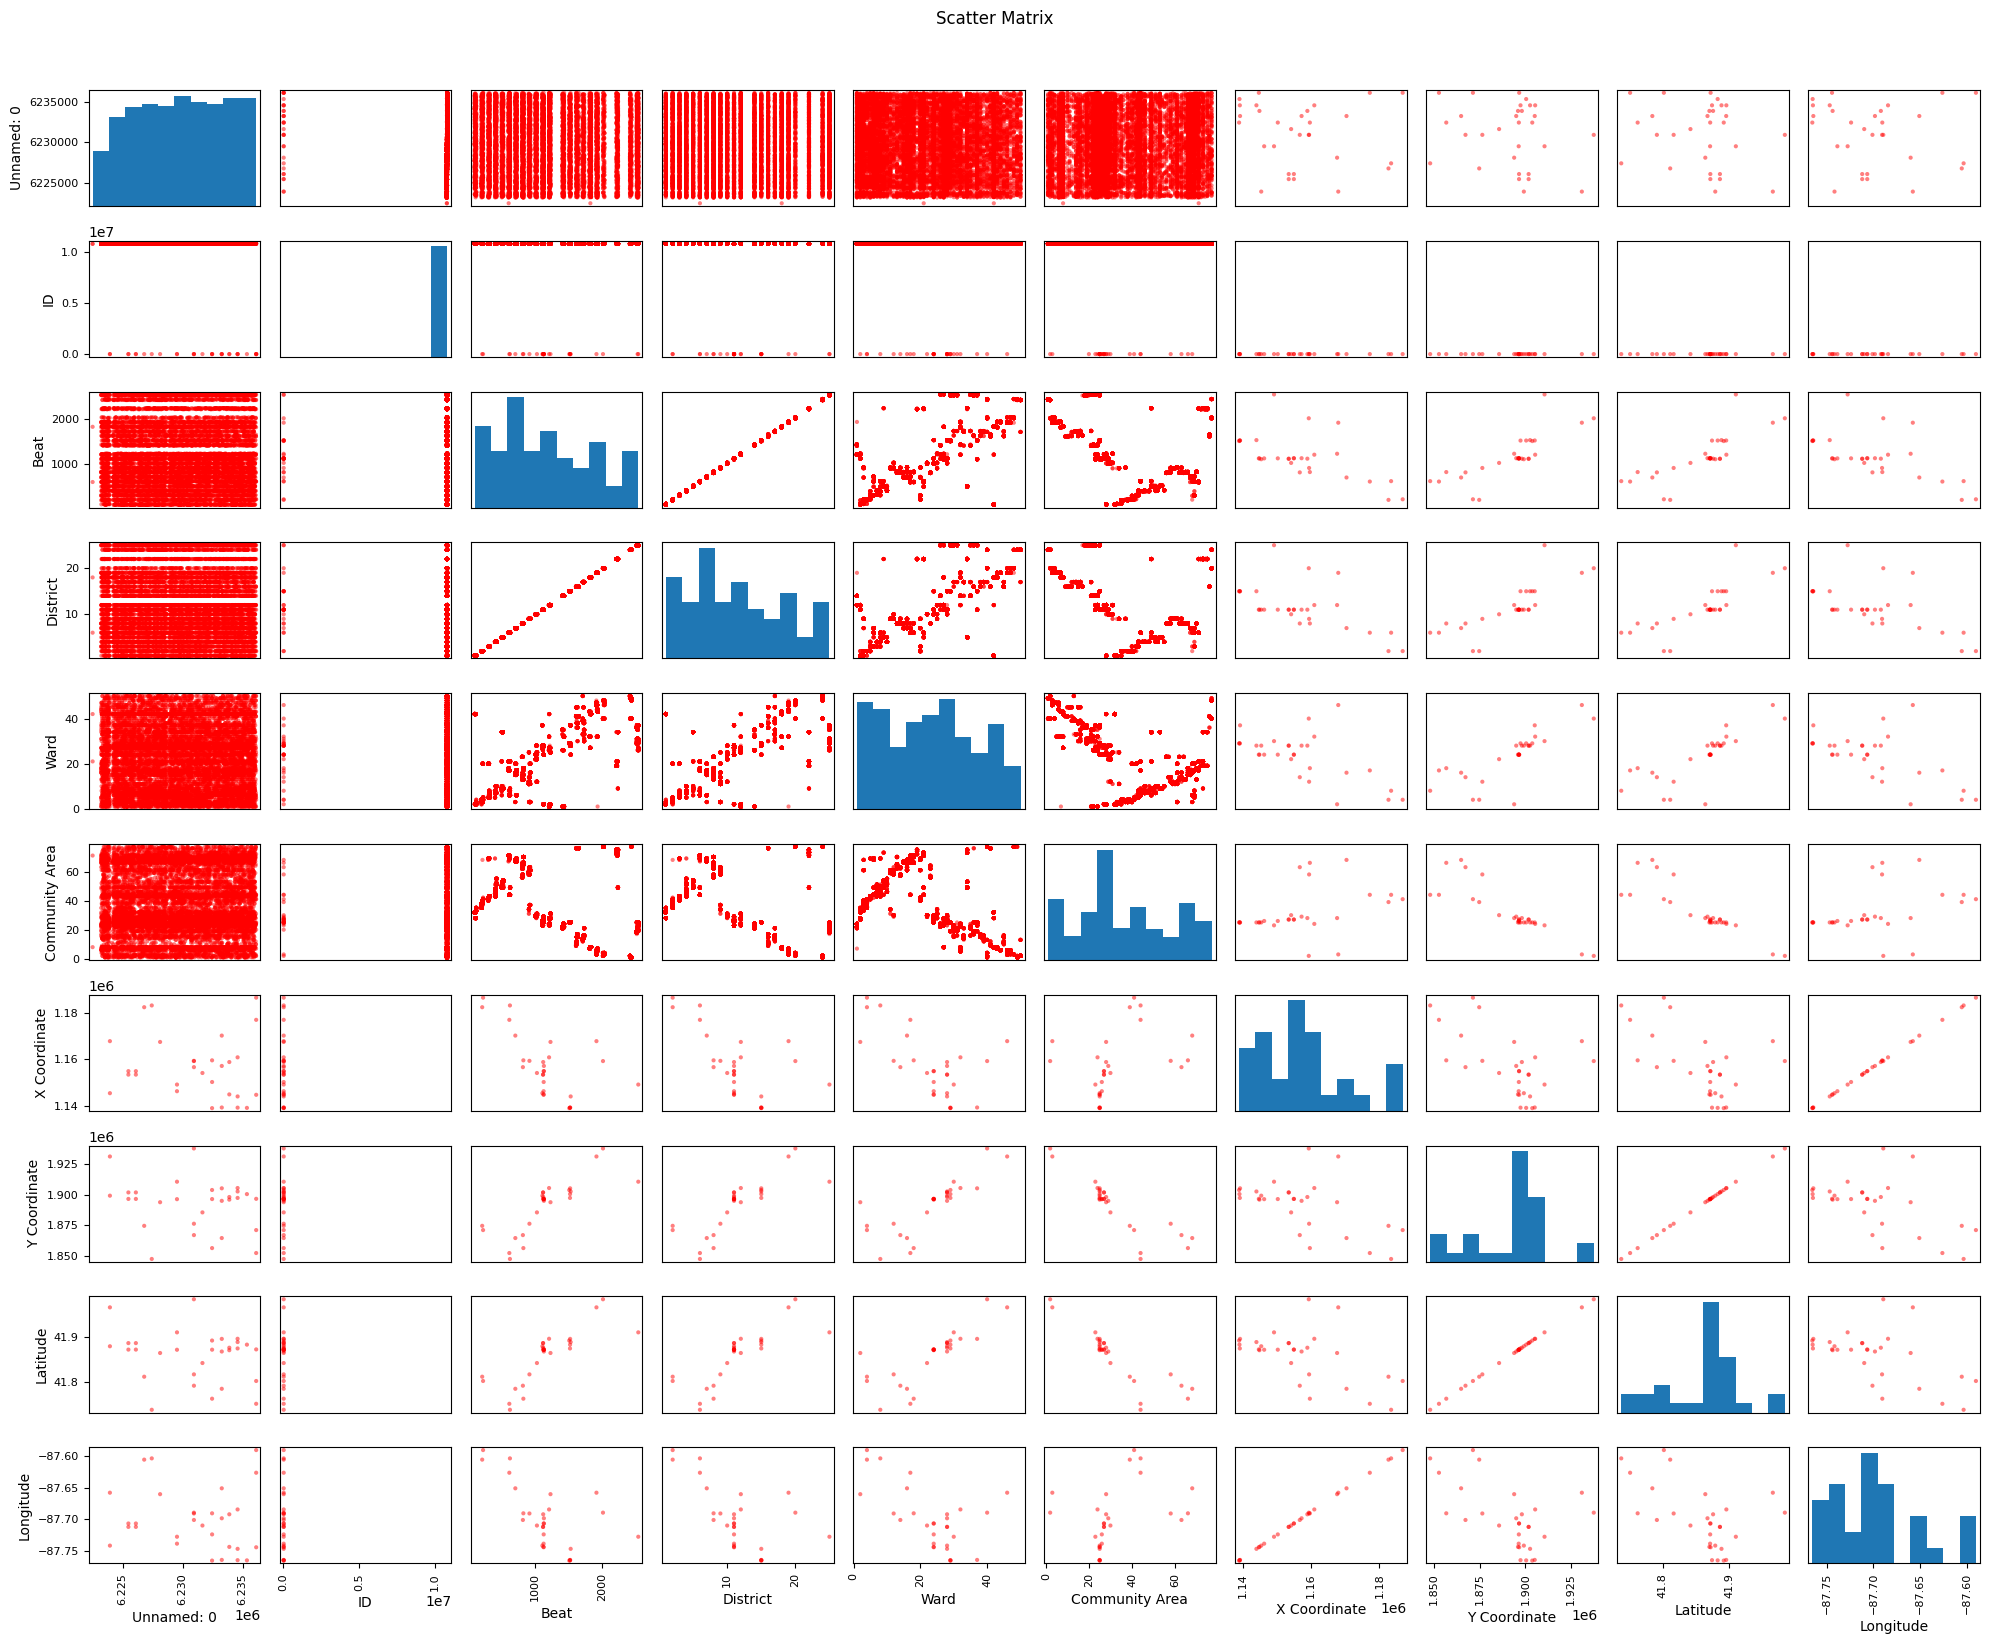

In [ ]:
#############################  Compréhension des données  #############################
# les variables du dataframe
print('Les variables du dataframe :')
print(df.columns)
print(df.shape)

# Types des variables
print("Types des variables : \n", df.dtypes)

# Statistiques descriptives
print('Statistiques descriptives : \n', df.describe())

# Sélectionner uniquement les colonnes numériques
df_num = df.select_dtypes(include='number')
df_num = df_num.drop('Year',axis = 1)

# Visualisations
# Histogrammes
print("Histogrammes :")
for col in df_num.columns:
    plt.figure(figsize=(8, 5))
    df_num[col].dropna().hist(bins=20, color='red', edgecolor='black')
    plt.title(f"Histogramme de {col}")
    plt.xlabel("Valeurs")
    plt.ylabel("Fréquences")
    plt.tight_layout()
    plt.show()

# Boxplots
print("Boxplots :")
for col in df_num.columns:
    plt.figure(figsize=(8, 5))
    df_num[col].dropna().plot(kind='box', color='red', patch_artist=True)
    plt.title(f"Boxplot de {col}")
    plt.ylabel("Valeurs")
    plt.tight_layout()
    plt.show()

# matrice de correlation

corr = df_num.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True,fmt='.2f',cmap='coolwarm',center=0,linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.tight_layout()
plt.show()

# Scatter plots
scatter_matrix(df_num, figsize=(20, 16), color='red', alpha=0.5,diagonal='hist')
plt.suptitle("Scatter Matrix", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
#############################   Prétraitement des données   #############################
# determiner les informations des données
print('type des colonnes :')
print(df.info())

# determiner le nombre des valeurs nulle
print('Le nombre de valeur nulle :')
print(df.isna().sum())



df['Location Description'] = df['Location Description'].fillna(df['Location Description'].mode()[0])


# supprimer les colonnes nulles
df = df.dropna(axis = 1)

# convertire bool -> int
df['Arrest']   = df['Arrest'].astype(int)
df['Domestic'] = df['Domestic'].astype(int)

# Afficher les colonnes catégorielles
cols_categoriques = df.select_dtypes(include=['object']).columns.tolist()
print('Colonnes catégorielles :')
print(cols_categoriques)

# one-hot encoding
cols_onehot = ['Primary Type', 'Location Description', 'FBI Code']
# Ensure only existing columns are passed to get_dummies
cols_onehot_actual = [col for col in cols_onehot if col in df.columns]
df = pd.get_dummies(df, columns=cols_onehot_actual, drop_first=True)
print("one hote",df.shape)
# Extraction des nouveaux variables à partir de la variable Date
df['Date'] = pd.to_datetime(df['Date'])
df['Heure']  = df['Date'].dt.hour
df['Mois']   = df['Date'].dt.month
df['Jour']   = df['Date'].dt.dayofweek
df = df.drop(columns=['Date'])

# supprimer les variable initule
cols_a_supprimer = ['Case Number', 'Block', 'IUCR',
                    'Description', 'Updated On', 'Unnamed: 0']

# Ensure only existing columns are dropped
cols_a_supprimer_actual = [col for col in cols_a_supprimer if col in df.columns]
df = df.drop(columns=cols_a_supprimer_actual)

# Application de isolation forest
cols_numeriques = df.select_dtypes(include=['int64','float64']).columns.tolist()
df_numeric = df[cols_numeriques]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=100
)

df['outlier'] = iso_forest.fit_predict(df_numeric)

print(f"Outliers détectés : {(df['outlier'] == -1).sum()}")
print(f"Points normaux    : {(df['outlier'] == 1).sum()}")

# Supprimer les outliers
df = df[df['outlier'] == 1].drop(columns=['outlier'])

# Normaliser les données
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)

type des colonnes :
<class 'pandas.core.frame.DataFrame'>
Index: 11357 entries, 1443068 to 1456655
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            11357 non-null  int64  
 1   ID                    11357 non-null  int64  
 2   Case Number           11357 non-null  object 
 3   Date                  11357 non-null  object 
 4   Block                 11357 non-null  object 
 5   IUCR                  11357 non-null  object 
 6   Primary Type          11357 non-null  object 
 7   Description           11357 non-null  object 
 8   Location Description  11329 non-null  object 
 9   Arrest                11357 non-null  bool   
 10  Domestic              11357 non-null  bool   
 11  Beat                  11357 non-null  int64  
 12  District              11357 non-null  float64
 13  Ward                  11357 non-null  float64
 14  Community Area        11357 non-null  float64
 

=== Réduction PCA ===


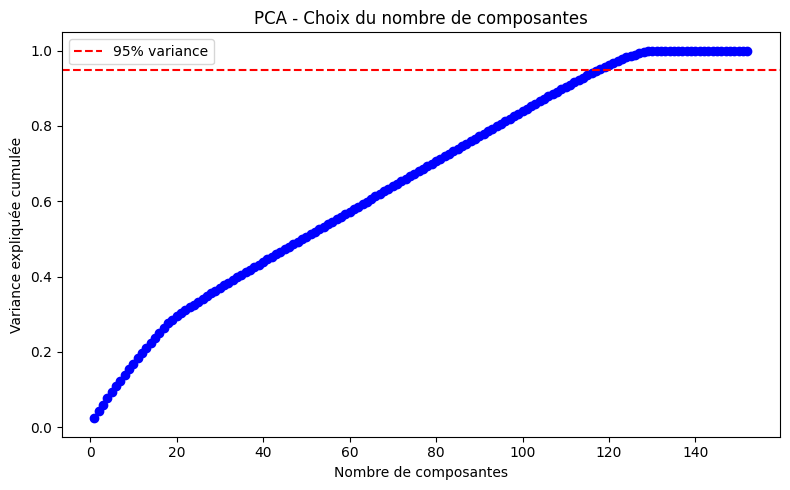

Nombre de composantes pour 95% de variance : 118
Shape après PCA : (10789, 118)
PCA effectué ✅


In [ ]:
#############################   Réduction de dimension - PCA   #############################

print("=== Réduction PCA ===")

# Visualisation de la variance expliquée cumulée
pca_full = PCA()
pca_full.fit(df_scaled)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, 'bo-')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('PCA - Choix du nombre de composantes')
plt.legend()
plt.tight_layout()
plt.show()

# Nombre de composantes pour 95% de variance
n_components = np.argmax(variance_cumulee >= 0.95) + 1
print(f"Nombre de composantes pour 95% de variance : {n_components}")

# PCA pour le clustering
pca = PCA(n_components=n_components)
df_pca = pca.fit_transform(df_scaled)
print(f"Shape après PCA : {df_pca.shape}")
print("PCA effectué ✅")

In [ ]:
#############################   Réduction de dimension - UMAP   #############################
print("=== Réduction UMAP ===")
reducer = umap.UMAP(n_components=2, random_state=42)
df_umap = reducer.fit_transform(df_pca)
print(f"Shape après UMAP : {df_umap.shape}")

print("UMAP effectué ✅")

=== Réduction UMAP ===


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Shape après UMAP : (10789, 2)
UMAP effectué ✅



=== K-Means ===


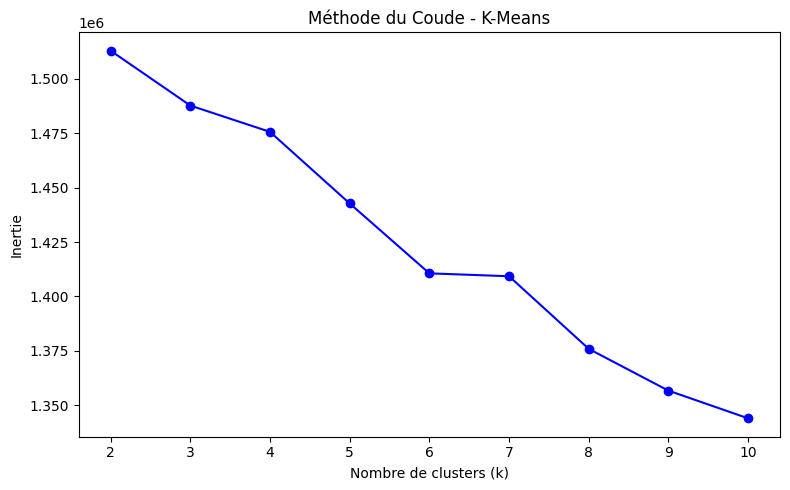

K optimal : 6


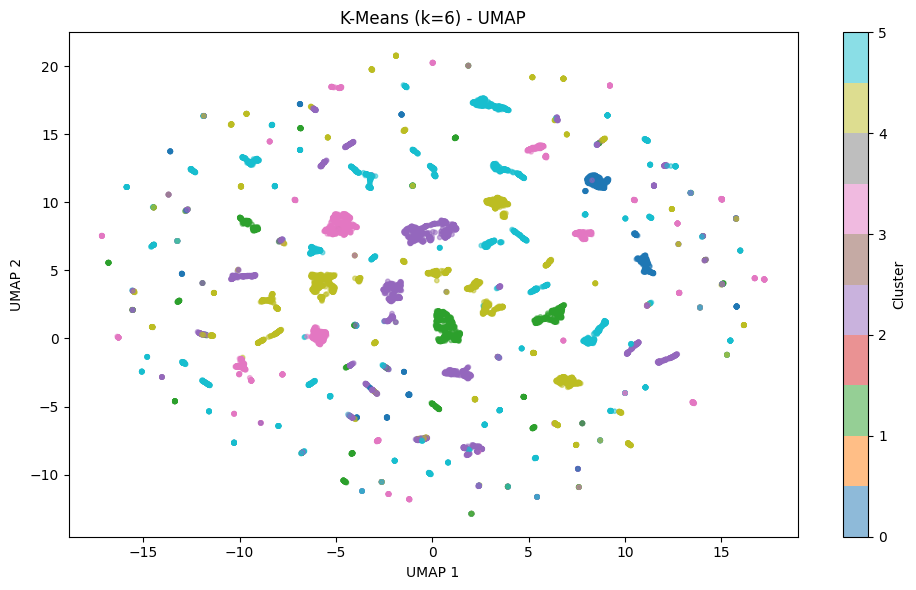


=== DBSCAN ===


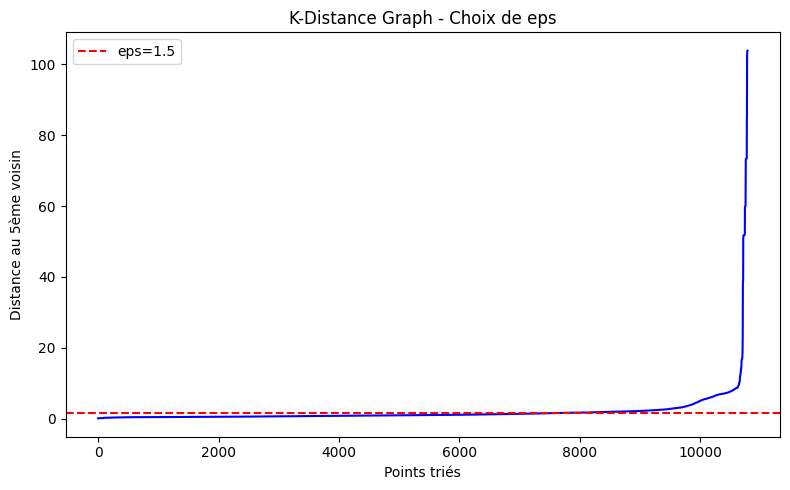

Clusters détectés : 100
Points bruit      : 3991


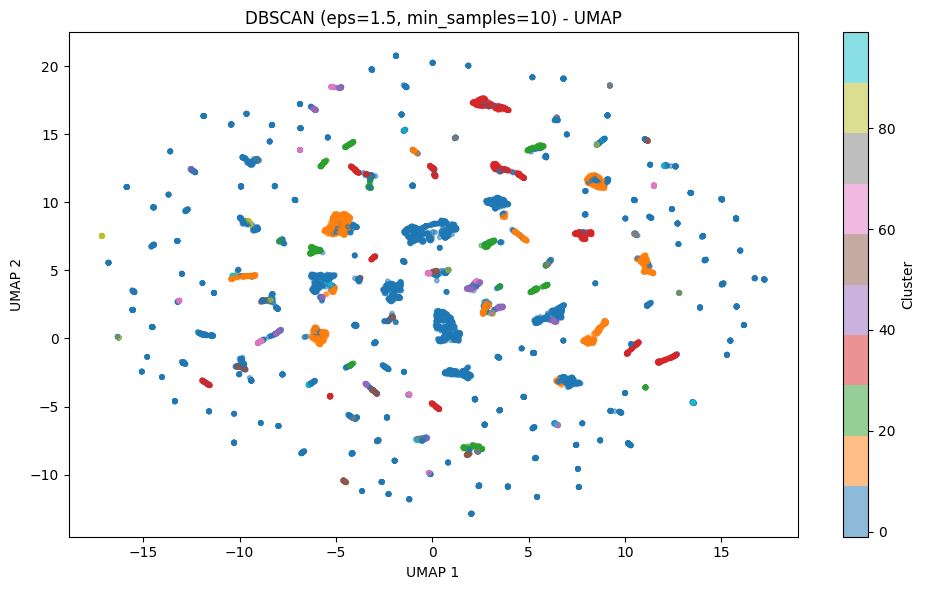


=== HDBSCAN ===
Clusters détectés : 16
Points bruit      : 4616


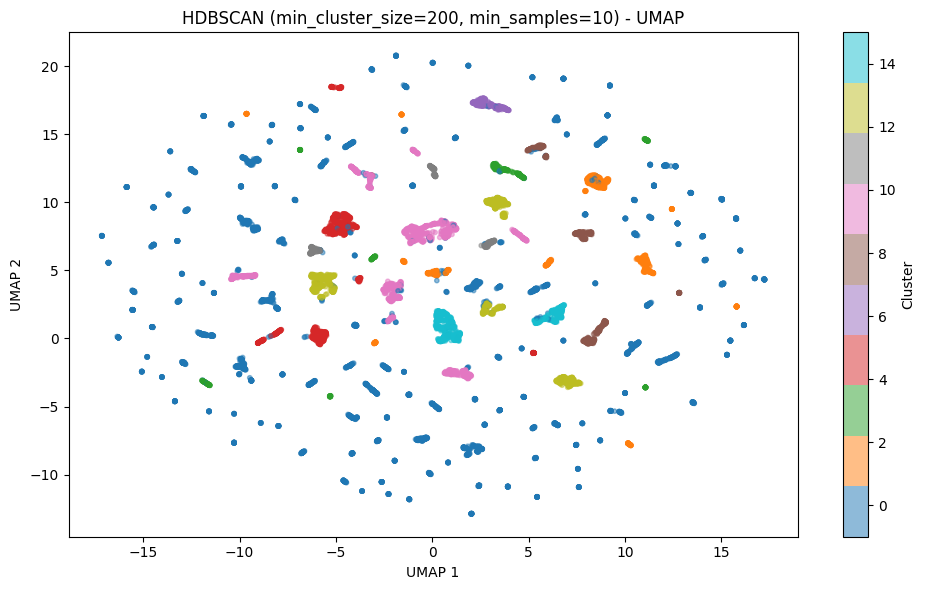


=== Gaussian Mixture Models (GMM) ===


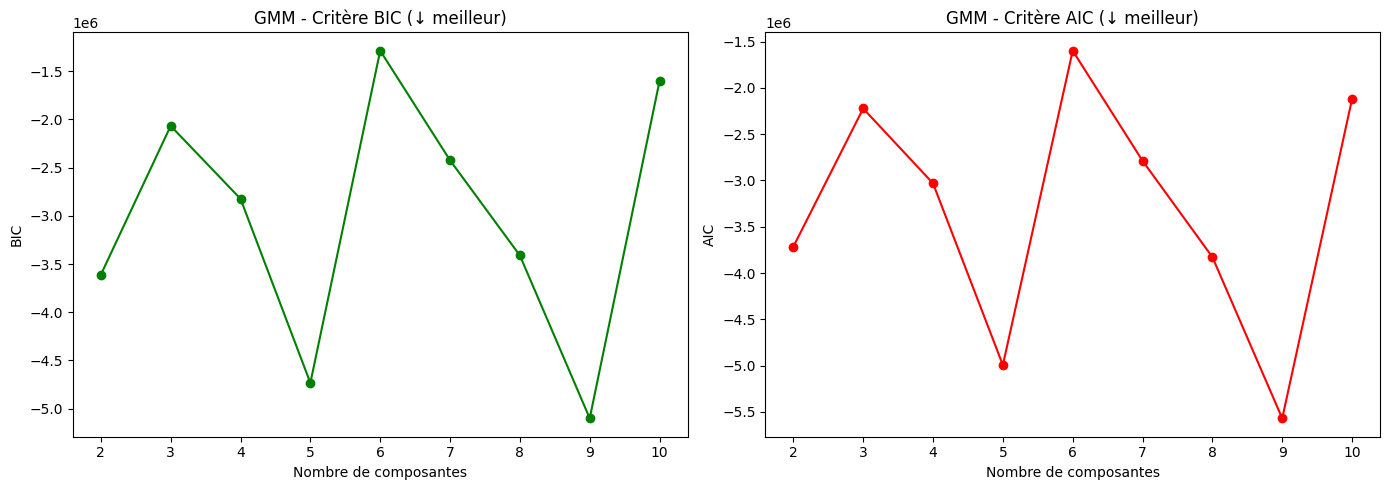

K optimal GMM : 9


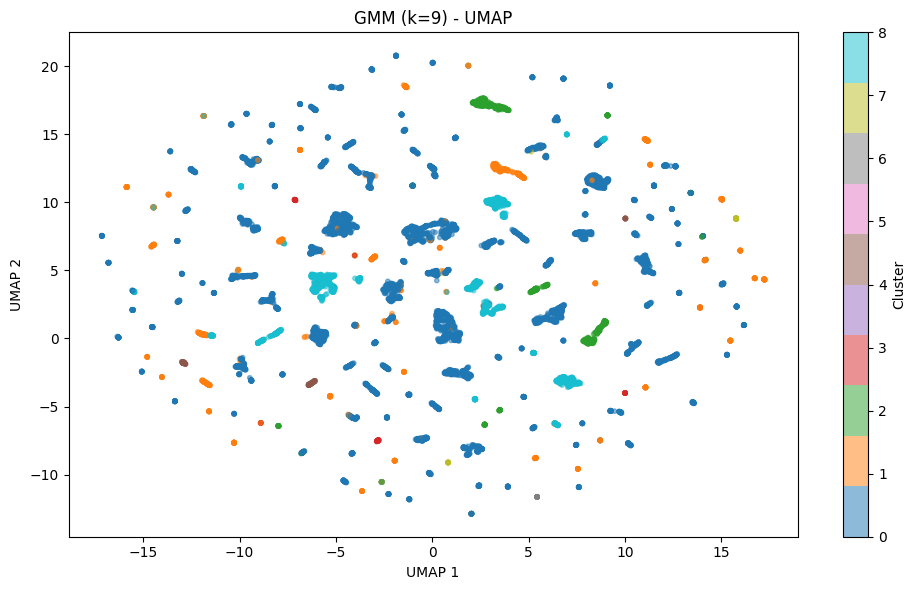


=== Comparaison des algorithmes ===
  Algorithme  Nb Clusters  Points Bruit
0    K-Means            6             0
1     DBSCAN          100          3991
2    HDBSCAN           16          4616
3        GMM            9             0


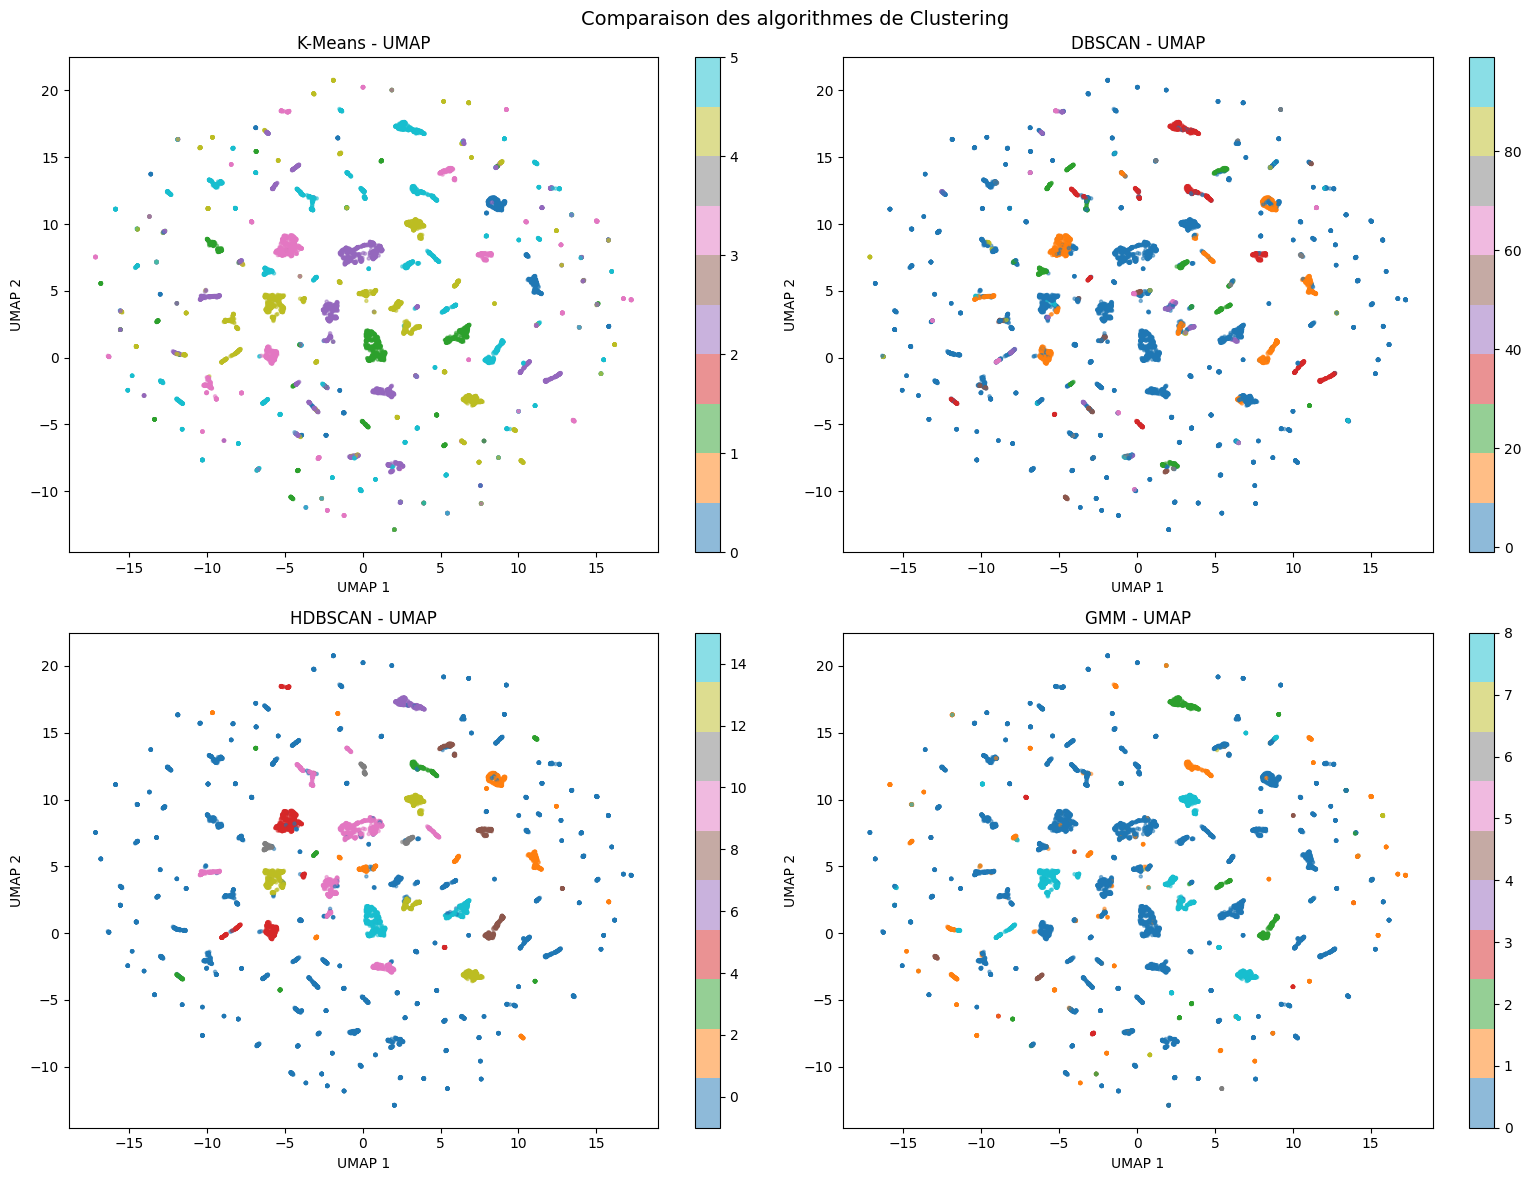

In [ ]:
#############################   K-Means   #############################

print("\n=== K-Means ===")

# Méthode du coude pour choisir k
inerties = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inerties.append(kmeans.inertia_)

# Visualisation méthode du coude
plt.figure(figsize=(8, 5))
plt.plot(K, inerties, 'bo-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude - K-Means')
plt.tight_layout()
plt.show()

# K optimal
k_optimal = 6  # augmenté car les crimes ont plus de 4 types distincts
print(f"K optimal : {k_optimal}")

# Appliquer K-Means avec paramètres améliorés
kmeans = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=20,       # plus d'initialisations → meilleure convergence
    max_iter=500,    # plus d'itérations → meilleure stabilité
    algorithm='lloyd'
)
labels_kmeans = kmeans.fit_predict(df_pca)

# Visualisation UMAP
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap[:, 0], df_umap[:, 1],
                      c=labels_kmeans, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means (k={k_optimal}) - UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

#############################   DBSCAN   #############################

print("\n=== DBSCAN ===")

# Trouver eps optimal avec k-distance graph
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(df_pca)
distances, _ = neighbors.kneighbors(df_pca)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances, 'b-')
plt.xlabel('Points triés')
plt.ylabel('Distance au 5ème voisin')
plt.title('K-Distance Graph - Choix de eps')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5')
plt.legend()
plt.tight_layout()
plt.show()

# Paramètres optimisés
dbscan = DBSCAN(
    eps=1.5,          # augmenté pour réduire le nombre de clusters
    min_samples=10,   # augmenté pour plus de robustesse
    metric='euclidean',
    n_jobs=-1         # utiliser tous les CPU
)
labels_dbscan = dbscan.fit_predict(df_pca)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_bruit_db    = (labels_dbscan == -1).sum()

print(f"Clusters détectés : {n_clusters_db}")
print(f"Points bruit      : {n_bruit_db}")

# Visualisation UMAP
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap[:, 0], df_umap[:, 1],
                      c=labels_dbscan, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'DBSCAN (eps=1.5, min_samples=10) - UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

#############################   HDBSCAN   #############################

print("\n=== HDBSCAN ===")

# Paramètres optimisés
hdb = hdbscan.HDBSCAN(
    min_cluster_size=200,  # augmenté pour avoir moins de clusters
    min_samples=10,        # augmenté pour plus de robustesse
    cluster_selection_method='eom',  # Excess of Mass → clusters plus stables
    metric='euclidean',
    prediction_data=True   # permet de prédire les nouveaux points
)
labels_hdbscan = hdb.fit_predict(df_pca)

n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_bruit_hdb    = (labels_hdbscan == -1).sum()

print(f"Clusters détectés : {n_clusters_hdb}")
print(f"Points bruit      : {n_bruit_hdb}")

# Visualisation UMAP
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap[:, 0], df_umap[:, 1],
                      c=labels_hdbscan, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'HDBSCAN (min_cluster_size=200, min_samples=10) - UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

#############################   GMM   #############################

print("\n=== Gaussian Mixture Models (GMM) ===")

# Critère BIC pour choisir k
bic_scores = []
aic_scores = []
K_gmm = range(2, 11)

for k in K_gmm:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42,
        covariance_type='full',  # matrice de covariance complète
        n_init=5,                # plusieurs initialisations
        max_iter=200
    )
    gmm.fit(df_pca)
    bic_scores.append(gmm.bic(df_pca))
    aic_scores.append(gmm.aic(df_pca))

# Visualisation BIC et AIC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_gmm, bic_scores, 'go-')
axes[0].set_xlabel('Nombre de composantes')
axes[0].set_ylabel('BIC')
axes[0].set_title('GMM - Critère BIC (↓ meilleur)')

axes[1].plot(K_gmm, aic_scores, 'ro-')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('AIC')
axes[1].set_title('GMM - Critère AIC (↓ meilleur)')
plt.tight_layout()
plt.show()

# K optimal GMM
k_gmm_optimal = bic_scores.index(min(bic_scores)) + 2
print(f"K optimal GMM : {k_gmm_optimal}")

# Appliquer GMM avec paramètres optimisés
gmm = GaussianMixture(
    n_components=k_gmm_optimal,
    random_state=42,
    covariance_type='full',
    n_init=5,
    max_iter=200
)
labels_gmm = gmm.fit_predict(df_pca)

# Visualisation UMAP
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap[:, 0], df_umap[:, 1],
                      c=labels_gmm, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'GMM (k={k_gmm_optimal}) - UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

#############################   Comparaison   #############################

print("\n=== Comparaison des algorithmes ===")

resultats = pd.DataFrame({
    'Algorithme'  : ['K-Means', 'DBSCAN', 'HDBSCAN', 'GMM'],
    'Nb Clusters' : [k_optimal, n_clusters_db, n_clusters_hdb, k_gmm_optimal],
    'Points Bruit': [0, n_bruit_db, n_bruit_hdb, 0]
})
print(resultats)

# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
labels_list = [labels_kmeans, labels_dbscan, labels_hdbscan, labels_gmm]
titres      = ['K-Means', 'DBSCAN', 'HDBSCAN', 'GMM']

for ax, labels, titre in zip(axes.flatten(), labels_list, titres):
    scatter = ax.scatter(df_umap[:, 0], df_umap[:, 1],
                         c=labels, cmap='tab10', alpha=0.5, s=5)
    plt.colorbar(scatter, ax=ax)
    ax.set_title(f'{titre} - UMAP')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.suptitle('Comparaison des algorithmes de Clustering', fontsize=14)
plt.tight_layout()
plt.show()


=== K-Means ===
Silhouette Score        : 0.0433  (meilleur → 1)
Davies-Bouldin Index    : 3.3522   (meilleur → 0)
Calinski-Harabasz Index : 198.19 (meilleur → max)

=== DBSCAN ===
Silhouette Score        : 0.3667  (meilleur → 1)
Davies-Bouldin Index    : 1.0091   (meilleur → 0)
Calinski-Harabasz Index : 710.70 (meilleur → max)

=== HDBSCAN ===
Silhouette Score        : 0.4018  (meilleur → 1)
Davies-Bouldin Index    : 1.0901   (meilleur → 0)
Calinski-Harabasz Index : 1363.63 (meilleur → max)

=== GMM ===
Silhouette Score        : 0.0516  (meilleur → 1)
Davies-Bouldin Index    : 2.7749   (meilleur → 0)
Calinski-Harabasz Index : 138.56 (meilleur → max)

=== Tableau comparatif des métriques ===
Algorithme  Silhouette  Davies_Bouldin  Calinski_Harabasz
   K-Means    0.043274        3.352201         198.193242
    DBSCAN    0.366682        1.009120         710.698741
   HDBSCAN    0.401824        1.090095        1363.631224
       GMM    0.051639        2.774910         138.561460


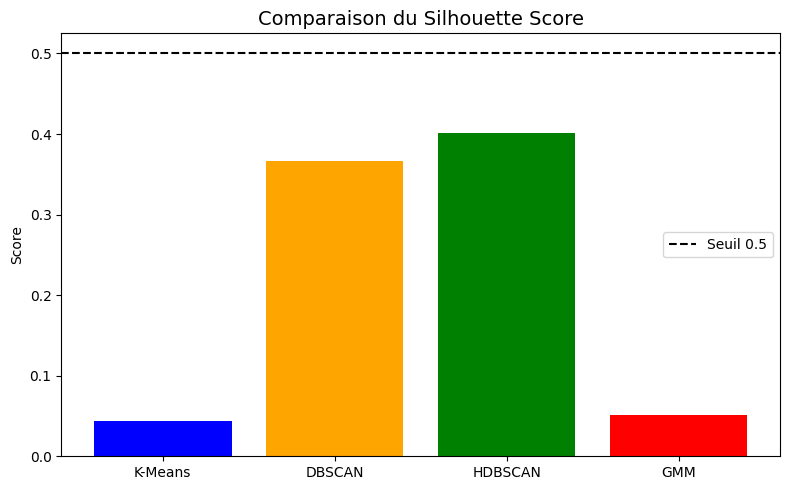

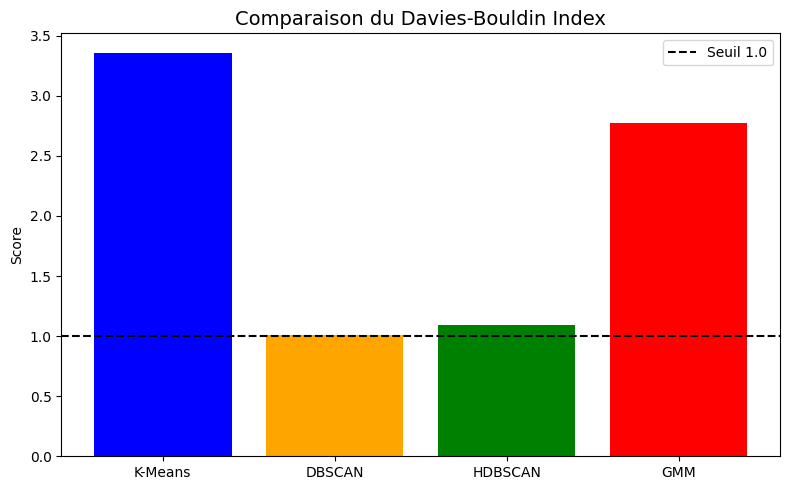

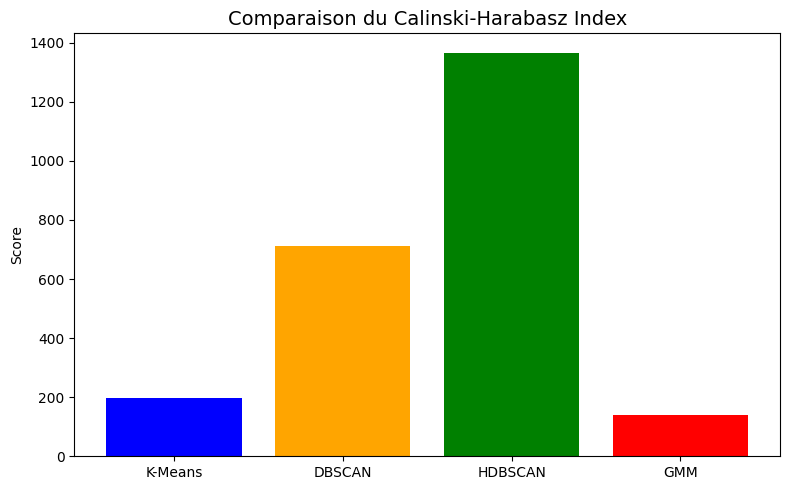


=== Interprétation Cohésion / Séparation ===

K-Means :
  Cohésion intra-cluster  : ❌ Faible  (Silhouette=0.0433)
  Séparation inter-cluster: ❌ Faible  (Davies-Bouldin=3.3522)

DBSCAN :
  Cohésion intra-cluster  : ⚠️ Moyenne (Silhouette=0.3667)
  Séparation inter-cluster: ⚠️ Moyenne (Davies-Bouldin=1.0091)

HDBSCAN :
  Cohésion intra-cluster  : ⚠️ Moyenne (Silhouette=0.4018)
  Séparation inter-cluster: ⚠️ Moyenne (Davies-Bouldin=1.0901)

GMM :
  Cohésion intra-cluster  : ❌ Faible  (Silhouette=0.0516)
  Séparation inter-cluster: ❌ Faible  (Davies-Bouldin=2.7749)


In [ ]:
#############################   Métriques de clustering   #############################

# Fonction pour calculer les 3 métriques
def evaluer_clustering(labels, data, nom):
    print(f"\n=== {nom} ===")

    # Filtrer les points bruit (-1) pour DBSCAN et HDBSCAN
    mask = labels != -1
    labels_filtre = labels[mask]
    data_filtre   = data[mask]

    if len(set(labels_filtre)) < 2:
        print("Pas assez de clusters pour évaluer")
        return None, None, None

    # Calcul des métriques
    sil = silhouette_score(data_filtre, labels_filtre)
    db  = davies_bouldin_score(data_filtre, labels_filtre)
    ch  = calinski_harabasz_score(data_filtre, labels_filtre)

    print(f"Silhouette Score        : {sil:.4f}  (meilleur → 1)")
    print(f"Davies-Bouldin Index    : {db:.4f}   (meilleur → 0)")
    print(f"Calinski-Harabasz Index : {ch:.2f} (meilleur → max)")

    return sil, db, ch

# Évaluation de chaque algorithme
sil_km,  db_km,  ch_km  = evaluer_clustering(labels_kmeans,  df_pca, 'K-Means')
sil_db,  db_db,  ch_db  = evaluer_clustering(labels_dbscan,  df_pca, 'DBSCAN')
sil_hdb, db_hdb, ch_hdb = evaluer_clustering(labels_hdbscan, df_pca, 'HDBSCAN')
sil_gmm, db_gmm, ch_gmm = evaluer_clustering(labels_gmm,     df_pca, 'GMM')

# Tableau comparatif  ← noms de colonnes SANS espaces
df_metriques = pd.DataFrame({
    'Algorithme'         : ['K-Means', 'DBSCAN', 'HDBSCAN', 'GMM'],
    'Silhouette'         : [sil_km,  sil_db,  sil_hdb,  sil_gmm],
    'Davies_Bouldin'     : [db_km,   db_db,   db_hdb,   db_gmm],
    'Calinski_Harabasz'  : [ch_km,   ch_db,   ch_hdb,   ch_gmm]
})

print("\n=== Tableau comparatif des métriques ===")
print(df_metriques.to_string(index=False))

# Visualisation des métriques

# Silhouette Score
plt.figure(figsize=(8, 5))
plt.bar(df_metriques['Algorithme'], df_metriques['Silhouette'],
        color=['blue', 'orange', 'green', 'red'])
plt.title('Comparaison du Silhouette Score', fontsize=14)
plt.ylabel('Score')
plt.axhline(y=0.5, color='black', linestyle='--', label='Seuil 0.5')
plt.legend()
plt.tight_layout()
plt.show()

# Davies-Bouldin Index
plt.figure(figsize=(8, 5))
plt.bar(df_metriques['Algorithme'], df_metriques['Davies_Bouldin'],
        color=['blue', 'orange', 'green', 'red'])
plt.title('Comparaison du Davies-Bouldin Index', fontsize=14)
plt.ylabel('Score')
plt.axhline(y=1.0, color='black', linestyle='--', label='Seuil 1.0')
plt.legend()
plt.tight_layout()
plt.show()

# Calinski-Harabasz Index
plt.figure(figsize=(8, 5))
plt.bar(df_metriques['Algorithme'], df_metriques['Calinski_Harabasz'],
        color=['blue', 'orange', 'green', 'red'])
plt.title('Comparaison du Calinski-Harabasz Index', fontsize=14)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# Interprétation cohésion / séparation
print("\n=== Interprétation Cohésion / Séparation ===")

for algo, sil, db, ch in zip(
    ['K-Means', 'DBSCAN', 'HDBSCAN', 'GMM'],
    [sil_km, sil_db, sil_hdb, sil_gmm],
    [db_km,  db_db,  db_hdb,  db_gmm],
    [ch_km,  ch_db,  ch_hdb,  ch_gmm]
):
    print(f"\n{algo} :")

    # Cohésion intra-cluster
    if sil > 0.5:
        print(f"  Cohésion intra-cluster  :  Bonne   (Silhouette={sil:.4f})")
    elif sil > 0.25:
        print(f"  Cohésion intra-cluster  :  Moyenne (Silhouette={sil:.4f})")
    else:
        print(f"  Cohésion intra-cluster  :  Faible  (Silhouette={sil:.4f})")

    # Séparation inter-cluster
    if db < 1.0:
        print(f"  Séparation inter-cluster:  Bonne   (Davies-Bouldin={db:.4f})")
    elif db < 2.0:
        print(f"  Séparation inter-cluster:  Moyenne (Davies-Bouldin={db:.4f})")
    else:
        print(f"  Séparation inter-cluster:  Faible  (Davies-Bouldin={db:.4f})")